In [2]:
import pandas as pd 
import numpy as np 

In [3]:
input_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
input_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
input_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning and pre-processing

In [6]:
# Replace blank spaces with NaN
input_df['TotalCharges'] = input_df['TotalCharges'].replace(" ", None)

# Convert to numeric
input_df['TotalCharges'] = pd.to_numeric(input_df['TotalCharges'])

# Check missing values
input_df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# Handle Missing Values
input_df['TotalCharges'] = input_df['TotalCharges'].fillna(input_df['TotalCharges'].median())

In [11]:
# Drop Irrelevant columns
# Customer ID is a unique identifier and does not contribute to the prediction of churn, 
# so we can safely drop it.
input_df.drop(columns=['customerID'], inplace=True)

In [12]:
# Convert Target to Binary
input_df['Churn'] = input_df['Churn'].map({'No': 0, 'Yes': 1})

In [13]:
input_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Exploratory Data Analysis (EDA)

In [14]:
# Target Distribution
input_df['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

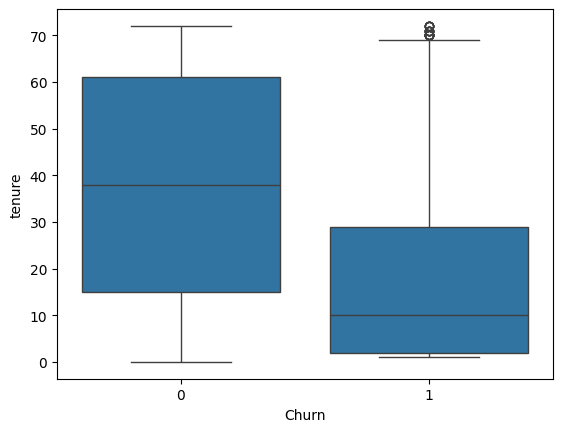

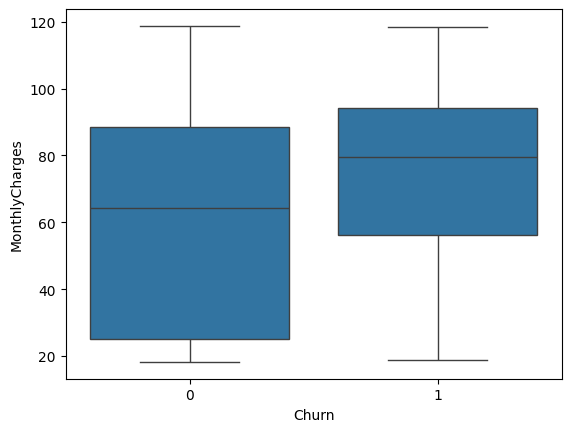

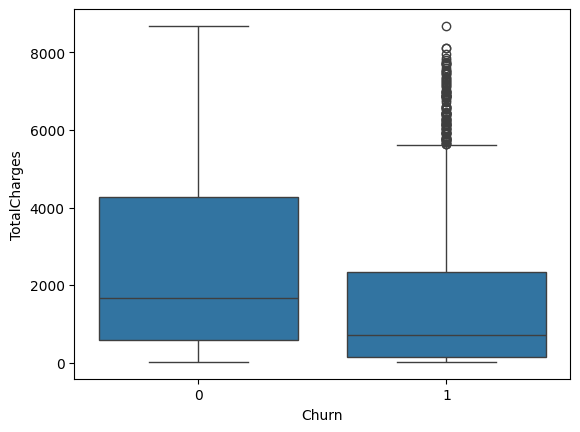

In [15]:
# Numerical Features Distribution

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    sns.boxplot(x='Churn', y=col, data=input_df)
    plt.show()

#### Observation
1. tenure → Strong negative correlation with churn
    ; Low tenure customers churn more

2. MonthlyCharges → Higher charges → more churn
3. TotalCharges → Lower total → more churn (because low tenure)

In [20]:
# Categorical Features Distribution

for col in input_df.select_dtypes(include='object').columns:
    print(pd.crosstab(input_df[col], input_df['Churn'], normalize='index'))

Churn          0         1
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603
Churn           0         1
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649
Churn              0         1
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502
Churn                0         1
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096
Churn                    0         1
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099
Churn                   0         1
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050
Churn                       0         1
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050

C:\Users\Genesis\AppData\Local\Temp\ipykernel_8724\699512097.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in input_df.select_dtypes(include='object').columns:


#### Observations:
1. Month-month contract have more churn
2. Paperless Billing has more churn
3. Electronic Check payment method has more churn
4. Without Tech support has more churn
5. Without Device Protection has more churn
6. Fiber optic customers have more churn

## Feature Engineering

In [21]:
# Tenure Binning (Customer Lifecycle)
# This helps tree models and even linear models capture lifecycle risk.

df = input_df.copy() 

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']
)

In [24]:
# Validate Consistency of Total Charges with Tenure and Monthly Charges
# This may help detect irregular billing patterns.

df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [25]:
# Service Count Feature (VERY Powerful)
# Customers with more services tend to churn less.

services = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

for col in services:
    df[col] = df[col].replace({'No internet service': 'No',
                               'No phone service': 'No'})

df['num_services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [27]:
# Contract Mapping (Ordinal Encoding)
# This gives monotonic relationship.

contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
df['Contract'] = df['Contract'].map(contract_map)

In [28]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

In [29]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,num_services
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,0,Yes,Electronic check,29.85,29.85,0,0-1yr,14.925000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,1,No,Mailed check,56.95,1889.50,0,2-4yr,53.985714,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,0,Yes,Mailed check,53.85,108.15,1,0-1yr,36.050000,3
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,1,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,40.016304,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,0,Yes,Electronic check,70.70,151.65,1,0-1yr,50.550000,1


## Encoding Strategy

In [ ]:
# For Linear Models (Logistic Regression)

# → One-hot encoding

# For Tree-Based Models (XGBoost, LightGBM)

# → Can use label encoding OR one-hot
# → Trees handle non-linearity well

df_encoded = pd.get_dummies(df, drop_first=True)

In [31]:
df_encoded.head()

,tenure,Contract,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,num_services,gender_Male,SeniorCitizen_1,Partner_Yes,...,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr
0,1,0,29.85,29.85,0,14.925000,1,False,False,True,...,False,False,True,False,True,False,False,False,False,False
1,34,1,56.95,1889.50,0,53.985714,3,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,2,0,53.85,108.15,1,36.050000,3,True,False,False,...,False,False,True,False,False,True,False,False,False,False
3,45,1,42.30,1840.75,0,40.016304,3,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,2,0,70.70,151.65,1,50.550000,1,False,False,False,...,False,False,True,False,True,False,False,False,False,False


## Correlation Check

In [33]:
df_encoded.columns

Index(['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'avg_monthly_spend', 'num_services', 'gender_Male', 'SeniorCitizen_1',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'tenure_group_1-2yr', 'tenure_group_2-4yr', 'tenure_group_4-5yr',
       'tenure_group_5-6yr'],
      dtype='str')

In [32]:
import numpy as np

corr = df_encoded.corr()
corr['Churn'].sort_values(ascending=False)  

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen_1                          0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
tenure_group_1-2yr                       0.020308
avg_monthly_spend                        0.014873
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
DeviceProtection_Yes                    -0.066160
num_services                            -0.067264
tenure_group_2-4yr                      -0.075312
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
tenure_group_4-5yr                      -0.100416
PaymentMethod_Credit card (automatic)   -0.134302


#### Observation
##### High Positive Correlation
1. InternetService_Fiber optic
2. PaymentMethod_Electronic check
3. MonthlyCharges
4. PaperlessBilling_Yes

##### High Negative Correlation
1. Contract
2. tenure
3. InternetService_No
4. tenure_group_5-6yr

## Additional Advanced Feature Ideas

In [35]:
# Interaction Features
df['high_charge_monthly'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
df['high_charge_m2m'] = df['high_charge_monthly'] * (df['Contract'] == 0)

In [36]:
# Churn Risk Segment
# Create composite risk:

df['risk_score'] = (
    (df['Contract'] == 0).astype(int) +
    (df['OnlineSecurity'] == 'No').astype(int) +
    (df['TechSupport'] == 'No').astype(int)
)

In [37]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,num_services,high_charge_monthly,high_charge_m2m,risk_score
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,Electronic check,29.85,29.85,0,0-1yr,14.925000,1,0,0,3
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,0,2-4yr,53.985714,3,0,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,0-1yr,36.050000,3,0,0,2
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,2-4yr,40.016304,3,0,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,0-1yr,50.550000,1,1,1,3


## Final Preprocessing


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'num_services']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Baseline Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Baseline model
baseline_model = LogisticRegression(max_iter=1000)
# baseline_model = LogisticRegression(
#     max_iter=1000,
#     class_weight='balanced'
# )

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.8463535611873207
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409

[[937  98]
 [178 196]]


### Forward Feature Selection

In [40]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold

log_reg = LogisticRegression(max_iter=1000)

sfs_forward = SequentialFeatureSelector(
    log_reg,
    n_features_to_select=15,   # You can tune this
    direction="forward",
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

sfs_forward.fit(X_train, y_train)

selected_features_forward = X_train.columns[sfs_forward.get_support()]

print("Selected Features (Forward):")
print(selected_features_forward)

Selected Features (Forward):
Index(['tenure', 'Contract', 'TotalCharges', 'avg_monthly_spend', 'risk_score',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'PaperlessBilling_Yes',
       'PaymentMethod_Electronic check', 'tenure_group_1-2yr'],
      dtype='str')


In [42]:
# Retrain
X_train_fwd = X_train[selected_features_forward]
X_test_fwd = X_test[selected_features_forward]

model_fwd = LogisticRegression(max_iter=1000)
model_fwd.fit(X_train_fwd, y_train)

y_prob_fwd = model_fwd.predict_proba(X_test_fwd)[:,1]
y_pred_fwd = model_fwd.predict(X_test_fwd)

print("Forward Selection ROC-AUC:", roc_auc_score(y_test, y_prob_fwd))
print(classification_report(y_test, y_pred_fwd))
print(confusion_matrix(y_test, y_pred_fwd))

Forward Selection ROC-AUC: 0.8465460228887339
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

[[936  99]
 [175 199]]


### Backward Feature Elimination

In [43]:
sfs_backward = SequentialFeatureSelector(
    log_reg,
    n_features_to_select=15,
    direction="backward",
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

sfs_backward.fit(X_train, y_train)

selected_features_backward = X_train.columns[sfs_backward.get_support()]

print("Selected Features (Backward):")
print(selected_features_backward)

Selected Features (Backward):
Index(['tenure', 'Contract', 'TotalCharges', 'avg_monthly_spend',
       'Dependents_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'PaperlessBilling_Yes', 'PaymentMethod_Electronic check'],
      dtype='str')


In [45]:
# retrain
X_train_bwd = X_train[selected_features_backward]
X_test_bwd = X_test[selected_features_backward]

model_bwd = LogisticRegression(max_iter=1000)
model_bwd.fit(X_train_bwd, y_train)

y_prob_bwd = model_bwd.predict_proba(X_test_bwd)[:,1]
y_pred_bwd = model_bwd.predict(X_test_bwd)

print("Backward Selection ROC-AUC:", roc_auc_score(y_test, y_prob_bwd))
print(classification_report(y_test, y_pred_bwd))
print(confusion_matrix(y_test, y_pred_bwd))

Backward Selection ROC-AUC: 0.8463742282156603
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

[[938  97]
 [175 199]]
